# Ablation IMV - UCI HAR / recurrent sequence model

Architectural ablation of a recurrent neural network on smartphone inertial
signals, scored with the installed `imv` package.

The openly licensed (CC BY 4.0)
[UCI Human Activity Recognition dataset](https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones)
contains fixed 2.56-second windows from waist-mounted accelerometers and
gyroscopes. `AblationIMV` currently compares binary probabilistic predictions,
so this notebook studies a natural directional task: **walking upstairs (1)
versus walking downstairs (0)**.

The supplied split is subject-disjoint: 21 participants contribute training
windows and 9 different participants contribute test windows. We preserve that
split exactly and fit normalization on training subjects only.

**Pipeline**: download the official openly licensed archive -> load nine
128-step inertial channels -> select upstairs/downstairs windows -> train five
recurrent variants over ten seeds -> calculate and visualize directional
ablation IMV.

This is a new example run, not a replication of a published result. It uses a
fixed 15-epoch compute budget. Restartable predictions and exported artifacts
are cached outside the repository under `~/.cache/imv`.

In [1]:
import gc
import io
import os
import sys
import tempfile
import time
import warnings
from pathlib import Path
from types import SimpleNamespace
from urllib.request import urlretrieve
from zipfile import ZipFile

_PATH_DISPLAY_ROOT = Path()

def relative_path(path, *, start=None):
    """Return a display-only path relative to an explicit local anchor."""
    anchor = Path(start) if start is not None else _PATH_DISPLAY_ROOT
    try:
        relative = os.path.relpath(Path(path).expanduser().resolve(),
                                   start=anchor.expanduser().resolve())
    except ValueError:  # Paths on different Windows drives cannot be relativized.
        relative = Path(path).name
    return Path(relative).as_posix()

def _relative_warning_text(message):
    text = str(message)
    roots = {Path.home(), Path(sys.prefix), Path(sys.base_prefix),
             _PATH_DISPLAY_ROOT, Path(tempfile.gettempdir())}
    for root in sorted(roots, key=lambda value: len(str(value)), reverse=True):
        absolute = str(root.expanduser().resolve())
        text = text.replace(absolute, relative_path(absolute))
    return text

def _show_relative_warning(message, category, filename, lineno, file=None, line=None):
    stream = file if file is not None else sys.stderr
    warning_text = _relative_warning_text(message)
    print(f"{relative_path(filename)}:{lineno}: {category.__name__}: {warning_text}", file=stream)

warnings.showwarning = _show_relative_warning

%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import imv
from imv import AblationIMV, information_deficit, ll
from imv.utils import plot_ablation_matrix, save_figure

# Fail fast if Jupyter is attached to a different installation of imv.
_HERE = Path().resolve()
REPOSITORY_ROOT = next((path for path in (_HERE, *_HERE.parents)
                        if (path / "pyproject.toml").is_file()
                        and (path / "src" / "imv").is_dir()), None)
if REPOSITORY_ROOT is None:
    raise RuntimeError("Run this notebook from inside the imv repository checkout.")
_PATH_DISPLAY_ROOT = REPOSITORY_ROOT
IMV_SOURCE = Path(imv.__file__).resolve().parent
EXPECTED_IMV_SOURCE = (REPOSITORY_ROOT / "src" / "imv").resolve()
if IMV_SOURCE != EXPECTED_IMV_SOURCE:
    raise RuntimeError("Expected repository package at "
                       f"{relative_path(EXPECTED_IMV_SOURCE)}, imported "
                       f"{relative_path(IMV_SOURCE)}")

CACHE = Path(os.environ.get("IMV_CACHE_HOME", Path.home() / ".cache" / "imv"))
DATA_HOME = Path(os.environ.get("IMV_DATA_CACHE", CACHE / "datasets")) / "uci_har"
ARTIFACTS = Path(os.environ.get("IMV_ARTIFACT_CACHE", CACHE / "notebook_artifacts")) / "ablation_imv_har"
RESULTS = ARTIFACTS / "results"; RESULTS.mkdir(parents=True, exist_ok=True)
FIGURES = ARTIFACTS / "figures"; FIGURES.mkdir(parents=True, exist_ok=True)

SEEDS = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]  # ten complete runs
BATCH, TEST_BATCH, EPOCHS, LR, HIDDEN = 128, 256, 15, 1e-3, 64
torch.set_num_threads(min(4, os.cpu_count() or 1))

# Constructing AblationIMV delegates device selection to the package.
ablator = AblationIMV(random_seed=SEEDS[0])
print(f"imv {imv.__version__} from {relative_path(IMV_SOURCE)}")
print("package class:", f"{AblationIMV.__module__}.{AblationIMV.__name__}")

Using device: CUDA GPU
GPU: NVIDIA GeForce RTX 4070
PyTorch version: 2.13.0+cu130
imv 1.2.0 from src/imv
package class: imv.ablation_imv.evaluator.AblationIMV


## 1. Download the official archive

The 58 MB archive is fetched directly from UCI and extracted under
`~/.cache/imv/datasets/uci_har` (or `IMV_DATA_CACHE/uci_har` when set). Nothing is stored
in the repository. UCI currently wraps the original `UCI HAR Dataset.zip`
inside its repository download, so the extraction handles that nested archive
explicitly.

In [2]:
DATA_URL = (
    "https://archive.ics.uci.edu/static/public/240/"
    "human+activity+recognition+using+smartphones.zip"
)
ARCHIVE = DATA_HOME / "human_activity_recognition_using_smartphones.zip"
DATA_ROOT = DATA_HOME / "UCI HAR Dataset"
REQUIRED = [
    DATA_ROOT / "train/y_train.txt",
    DATA_ROOT / "test/y_test.txt",
    DATA_ROOT / "train/Inertial Signals/body_acc_x_train.txt",
    DATA_ROOT / "test/Inertial Signals/body_acc_x_test.txt",
]


def safe_extract(bundle, destination):
    '''Extract a trusted archive only after rejecting path traversal entries.'''
    destination = destination.resolve()
    for member in bundle.infolist():
        target = (destination / member.filename).resolve()
        if target != destination and destination not in target.parents:
            raise ValueError(f"unsafe archive member: {member.filename}")
    bundle.extractall(destination)


if not all(path.is_file() for path in REQUIRED):
    DATA_HOME.mkdir(parents=True, exist_ok=True)
    if not ARCHIVE.is_file():
        print("downloading", DATA_URL)
        urlretrieve(DATA_URL, ARCHIVE)
    with ZipFile(ARCHIVE) as outer:
        nested = [name for name in outer.namelist() if name.endswith("UCI HAR Dataset.zip")]
        if nested:
            with ZipFile(io.BytesIO(outer.read(nested[0]))) as bundle:
                safe_extract(bundle, DATA_HOME)
        else:
            safe_extract(outer, DATA_HOME)

if not all(path.is_file() for path in REQUIRED):
    raise FileNotFoundError("UCI HAR extraction did not produce the required files")
print("dataset (relative to data cache):", relative_path(DATA_ROOT, start=DATA_HOME))

dataset (relative to data cache): UCI HAR Dataset


## 2. Load and preprocess the inertial sequences

Each example has 128 readings from nine channels: body acceleration, body
angular velocity, and total acceleration along the x/y/z axes. We use these
windowed signals rather than UCI's 561 engineered summary features.

Activity labels 2 and 3 are retained. Channel means and standard deviations are
estimated over training windows and time points, then applied unchanged to the
test subjects.

In [3]:
SIGNALS = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]
ACTIVITIES = {
    1: "WALKING", 2: "WALKING_UPSTAIRS", 3: "WALKING_DOWNSTAIRS",
    4: "SITTING", 5: "STANDING", 6: "LAYING",
}


def load_split(split):
    signal_dir = DATA_ROOT / split / "Inertial Signals"
    arrays = [
        np.loadtxt(signal_dir / f"{name}_{split}.txt", dtype=np.float32)
        for name in SIGNALS
    ]
    values = np.stack(arrays, axis=-1)
    labels = np.loadtxt(DATA_ROOT / split / f"y_{split}.txt", dtype=np.int64)
    subjects = np.loadtxt(DATA_ROOT / split / f"subject_{split}.txt", dtype=np.int64)
    keep = np.isin(labels, [2, 3])
    return values[keep], (labels[keep] == 2).astype(np.int64), subjects[keep], labels


train_values, train_labels_np, train_subjects, train_labels_raw = load_split("train")
test_values, test_labels_np, test_subjects, test_labels_raw = load_split("test")

assert train_values.shape == (2_059, 128, 9)
assert test_values.shape == (891, 128, 9)
assert np.intersect1d(train_subjects, test_subjects).size == 0
assert np.isfinite(train_values).all() and np.isfinite(test_values).all()

channel_mean = train_values.mean(axis=(0, 1), keepdims=True)
channel_std = train_values.std(axis=(0, 1), keepdims=True)
if np.any(channel_std == 0):
    raise ValueError("a training signal channel has zero variance")
train_values = ((train_values - channel_mean) / channel_std).astype(np.float32)
test_values = ((test_values - channel_mean) / channel_std).astype(np.float32)

train_labels = torch.from_numpy(train_labels_np)
test_labels = torch.from_numpy(test_labels_np)

def class_counts(labels):
    values, counts = np.unique(labels, return_counts=True)
    return {ACTIVITIES[int(value)]: int(count) for value, count in zip(values, counts)}

print("raw train:", (len(train_labels_raw), 128, len(SIGNALS)), class_counts(train_labels_raw))
print("raw test: ", (len(test_labels_raw), 128, len(SIGNALS)), class_counts(test_labels_raw))
print("binary train:", train_values.shape,
      {"downstairs": int((train_labels_np == 0).sum()), "upstairs": int(train_labels_np.sum())})
print("binary test: ", test_values.shape,
      {"downstairs": int((test_labels_np == 0).sum()), "upstairs": int(test_labels_np.sum())})
print("subjects:", len(np.unique(train_subjects)), "train /",
      len(np.unique(test_subjects)), "test; overlap = 0")

raw train: (7352, 128, 9) {'WALKING': 1226, 'WALKING_UPSTAIRS': 1073, 'WALKING_DOWNSTAIRS': 986, 'SITTING': 1286, 'STANDING': 1374, 'LAYING': 1407}
raw test:  (2947, 128, 9) {'WALKING': 496, 'WALKING_UPSTAIRS': 471, 'WALKING_DOWNSTAIRS': 420, 'SITTING': 491, 'STANDING': 532, 'LAYING': 537}
binary train: (2059, 128, 9) {'downstairs': 986, 'upstairs': 1073}
binary test:  (891, 128, 9) {'downstairs': 420, 'upstairs': 471}
subjects: 21 train / 9 test; overlap = 0


## 3. Recurrent variants

`FullBiGRU` uses two bidirectional GRU layers, recurrent dropout, and learned
temporal attention. Four variants remove distinct sources of sequence
information:

- `UniGRU`: removes the backward recurrent direction.
- `OneLayer`: removes the second recurrent layer.
- `NoAttention`: replaces learned temporal attention with mean pooling over GRU states.
- `MeanPoolMLP`: removes recurrence and temporal order, classifying channel means only.

The model returns `loss` and `logits` in the interface expected by
`AblationIMV.train_and_evaluate`; training and prediction come from the installed
package.

In [4]:
VARIANTS = ["FullBiGRU", "UniGRU", "OneLayer", "NoAttention", "MeanPoolMLP"]


class SignalDataset(Dataset):
    def __init__(self, values, labels):
        self.values = torch.from_numpy(values)
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return {"signals": self.values[index], "labels": self.labels[index]}


class HARNet(nn.Module):
    '''Bidirectional attentive GRU with explicit component ablations.'''

    def __init__(self, variant, hidden_size=HIDDEN):
        super().__init__()
        if variant not in VARIANTS:
            raise ValueError(f"unknown variant: {variant}")
        self.variant = variant

        if variant == "MeanPoolMLP":
            self.classifier = nn.Sequential(
                nn.Linear(len(SIGNALS), hidden_size),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(hidden_size, 2),
            )
            return

        layers = 1 if variant == "OneLayer" else 2
        bidirectional = variant != "UniGRU"
        self.gru = nn.GRU(
            len(SIGNALS), hidden_size, num_layers=layers, batch_first=True,
            bidirectional=bidirectional, dropout=0.3 if layers > 1 else 0.0,
        )
        output_size = hidden_size * (2 if bidirectional else 1)
        self.attention = None
        if variant != "NoAttention":
            self.attention = nn.Sequential(
                nn.Linear(output_size, hidden_size), nn.Tanh(), nn.Linear(hidden_size, 1)
            )
        self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(output_size, 2))

    def forward(self, signals, labels=None):
        if self.variant == "MeanPoolMLP":
            logits = self.classifier(signals.mean(dim=1))
        else:
            states, _ = self.gru(signals)
            if self.attention is None:
                pooled = states.mean(dim=1)
            else:
                weights = torch.softmax(self.attention(states), dim=1)
                pooled = (weights * states).sum(dim=1)
            logits = self.classifier(pooled)
        loss = None if labels is None else F.cross_entropy(logits, labels)
        return SimpleNamespace(loss=loss, logits=logits)


train_loader = DataLoader(
    SignalDataset(train_values, train_labels), batch_size=BATCH, shuffle=True
)
test_loader = DataLoader(
    SignalDataset(test_values, test_labels), batch_size=TEST_BATCH, shuffle=False
)

PARAMETERS = {}
for name in VARIANTS:
    model = HARNet(name)
    PARAMETERS[name] = sum(parameter.numel() for parameter in model.parameters())
    print(f"{name:<12} {PARAMETERS[name]:>10,} trainable parameters")

FullBiGRU       111,875 trainable parameters
UniGRU           43,715 trainable parameters
OneLayer         37,379 trainable parameters
NoAttention     103,554 trainable parameters
MeanPoolMLP         770 trainable parameters


## 4. Train and predict with the package

Every variant sees the same official training subjects and the same ordered test
windows. A seed controls initialization, minibatch order, recurrent dropout, and
head dropout. Before model construction we call the package seed method; the
package trainer sets it again immediately before optimization.

The 50 runs are restartable. A prediction CSV is reused only when its package
output columns, row count, aligned labels, and probabilities validate. Delete an
cached `predictions_har_*.csv` file to force that run to repeat. Repeated seeds
describe run-to-run stability, not a confidence interval, and accelerator
backends need not be bit-exact across machines.

In [5]:
def prediction_path(variant, seed):
    return RESULTS / f"predictions_har_{variant.lower()}_seed_{seed}.csv"


def valid_cached_predictions(path):
    if not path.exists():
        return False
    try:
        frame = pd.read_csv(path)
    except (OSError, pd.errors.ParserError):
        return False
    required = {"True Label", "Positive Probability", "Negative Probability", "Predicted Label"}
    if not required.issubset(frame.columns):
        return False
    positive = frame["Positive Probability"].to_numpy(float)
    negative = frame["Negative Probability"].to_numpy(float)
    return (
        len(frame) == len(test_labels)
        and np.array_equal(frame["True Label"].to_numpy(), test_labels.numpy())
        and np.isfinite(positive).all()
        and np.isfinite(negative).all()
        and ((0 <= positive) & (positive <= 1)).all()
        and ((0 <= negative) & (negative <= 1)).all()
        and np.allclose(positive + negative, 1.0, atol=1e-6)
    )


previous_path = RESULTS / "har_variant_diagnostics.csv"
if previous_path.exists():
    previous = pd.read_csv(previous_path)
    previous_minutes = {
        (int(row.seed), row.variant): float(row.minutes)
        for row in previous.itertuples() if pd.notna(row.minutes)
    }
else:
    previous_minutes = {}

seed_matrices, matrix_records, diagnostics = [], [], []
for seed in SEEDS:
    frames = {}
    print(f"seed {seed}")
    for variant in VARIANTS:
        path = prediction_path(variant, seed)
        started = time.perf_counter()
        cached = valid_cached_predictions(path)
        if cached:
            frame = pd.read_csv(path)
        else:
            ablator.set_seed(seed)
            model = HARNet(variant)
            run = ablator.train_and_evaluate(
                model,
                train_loader,
                test_loader,
                num_epochs=EPOCHS,
                lr=LR,
                optimizer_class=torch.optim.Adam,
                seed=seed,
                verbose=False,
            )
            frame = run["test_predictions"]
            frame.to_csv(path, index=False)
            del run, model
            gc.collect()
            if ablator.device.type == "cuda":
                torch.cuda.empty_cache()
            elif ablator.device.type == "mps":
                torch.mps.empty_cache()

        frames[variant] = frame
        y = frame["True Label"].to_numpy(float)
        p = frame["Positive Probability"].to_numpy(float)
        likelihood = ll(y, p)
        elapsed = (previous_minutes.get((seed, variant), float("nan")) if cached
                   else (time.perf_counter() - started) / 60)
        diagnostics.append(
            {
                "seed": seed,
                "variant": variant,
                "geometric_mean_likelihood": likelihood,
                "information_deficit_nats": information_deficit(likelihood),
                "accuracy": float(((p >= 0.5) == y).mean()),
                "parameters": PARAMETERS[variant],
                "minutes": elapsed,
                "cached": cached,
            }
        )
        note = "reused" if cached else f"{elapsed:.2f} min"
        print(f"  {variant:<12} a={likelihood:.5f} acc={diagnostics[-1]['accuracy']:.4f} ({note})")

    # This is the package's ablation-IMV calculation, not a notebook transcription.
    matrix = AblationIMV.calculate_imv_matrix(frames)
    seed_matrices.append(matrix)
    for enhanced in VARIANTS:
        for basic in VARIANTS:
            matrix_records.append(
                {"seed": seed, "enhanced": enhanced, "basic": basic,
                 "ablation_imv": matrix.loc[enhanced, basic]}
            )

diag = pd.DataFrame(diagnostics)
by_seed = pd.DataFrame(matrix_records)
diag.to_csv(RESULTS / "har_variant_diagnostics.csv", index=False)
by_seed.to_csv(RESULTS / "har_ablation_imv_by_seed.csv", index=False)
diag.groupby("variant")[["geometric_mean_likelihood", "information_deficit_nats", "accuracy"]].agg(["mean", "std"])

seed 42
  FullBiGRU    a=0.98556 acc=0.9933 (reused)
  UniGRU       a=0.72416 acc=0.9473 (reused)
  OneLayer     a=0.73665 acc=0.9607 (reused)
  NoAttention  a=0.84151 acc=0.9641 (reused)
  MeanPoolMLP  a=0.54877 acc=0.7374 (reused)
seed 43
  FullBiGRU    a=0.85379 acc=0.9731 (reused)
  UniGRU       a=0.85255 acc=0.9630 (reused)
  OneLayer     a=0.88736 acc=0.9742 (reused)
  NoAttention  a=0.88817 acc=0.9641 (reused)
  MeanPoolMLP  a=0.54075 acc=0.7419 (reused)
seed 44
  FullBiGRU    a=0.77695 acc=0.9607 (reused)
  UniGRU       a=0.76220 acc=0.9506 (reused)
  OneLayer     a=0.79434 acc=0.9675 (reused)
  NoAttention  a=0.93744 acc=0.9776 (reused)
  MeanPoolMLP  a=0.54355 acc=0.7340 (reused)
seed 45
  FullBiGRU    a=0.90509 acc=0.9742 (reused)
  UniGRU       a=0.90137 acc=0.9742 (reused)
  OneLayer     a=0.91273 acc=0.9686 (reused)
  NoAttention  a=0.92702 acc=0.9753 (reused)
  MeanPoolMLP  a=0.55046 acc=0.7374 (reused)
seed 46
  FullBiGRU    a=0.84509 acc=0.9742 (reused)
  UniGRU       

  FullBiGRU    a=0.81997 acc=0.9708 (0.03 min)


  UniGRU       a=0.77861 acc=0.9529 (0.01 min)


  OneLayer     a=0.78312 acc=0.9697 (0.01 min)


  NoAttention  a=0.85951 acc=0.9630 (0.01 min)


...

  UniGRU       a=0.76611 acc=0.9596 (0.01 min)


  OneLayer     a=0.93055 acc=0.9798 (0.01 min)


  NoAttention  a=0.86581 acc=0.9731 (0.01 min)


  MeanPoolMLP  a=0.54772 acc=0.7318 (0.00 min)


geometric_mean_likelihood           information_deficit_nats  \
                                 mean       std                     mean   
variant                                                                    
FullBiGRU                    0.853714  0.074515                 0.531613   
MeanPoolMLP                  0.544691  0.006360                 0.085549   
NoAttention                  0.875670  0.036583                 0.559604   
OneLayer                     0.835832  0.062441                 0.511306   
UniGRU                       0.820245  0.075345                 0.491282   

                       accuracy            
                  std      mean       std  
variant                                    
FullBiGRU    0.086282  0.973176  0.008954  
MeanPoolMLP  0.011635  0.739506  0.004247  
NoAttention  0.041459  0.969921  0.005041  
OneLayer     0.074762  0.969809  0.005407  
UniGRU       0.090340  0.961392  0.011927

## 5. Directional ablation IMV

`AblationIMV.calculate_imv_matrix` returns rows as **enhanced** models and
columns as **basic** models. The matrix is directional because each column uses
that basic model's equivalent-coin weight in the denominator; opposite cells
need not be negatives of one another.

The package's `average_imv_matrices` performs the elementwise mean over ten
seed-level matrices. Standard deviations are retained separately and are not
interpreted as confidence intervals.

In [6]:
mean_matrix = AblationIMV.average_imv_matrices(seed_matrices)
matrix_std = pd.DataFrame(
    np.std(np.stack([matrix.to_numpy() for matrix in seed_matrices]), axis=0, ddof=1),
    index=mean_matrix.index,
    columns=mean_matrix.columns,
)
mean_matrix.to_csv(RESULTS / "har_ablation_imv_directional.csv")
matrix_std.to_csv(RESULTS / "har_ablation_imv_directional_std.csv")

print("Mean directional ablation IMV over", len(SEEDS), "seeds")
print("rows = enhanced model; columns = basic model")
mean_matrix

Mean directional ablation IMV over 10 seeds
rows = enhanced model; columns = basic model


,FullBiGRU,UniGRU,OneLayer,NoAttention,MeanPoolMLP
FullBiGRU,0.000000,0.014839,0.006852,-0.010723,0.364011
UniGRU,-0.013566,0.000000,-0.007724,-0.024583,0.345348
OneLayer,-0.005060,0.008758,0.000000,-0.016714,0.355857
NoAttention,0.011649,0.026176,0.017552,0.000000,0.378952
MeanPoolMLP,-0.266253,-0.255468,-0.261910,-0.274620,0.000000


## 6. Figures

The first figure uses the package plotting helper and the same directional
heatmap convention as the IMDb and MNIST ablation examples. The second isolates
`FullBiGRU` as the enhanced model against each ablated baseline. Error bars are
seed standard deviations, not confidence intervals.

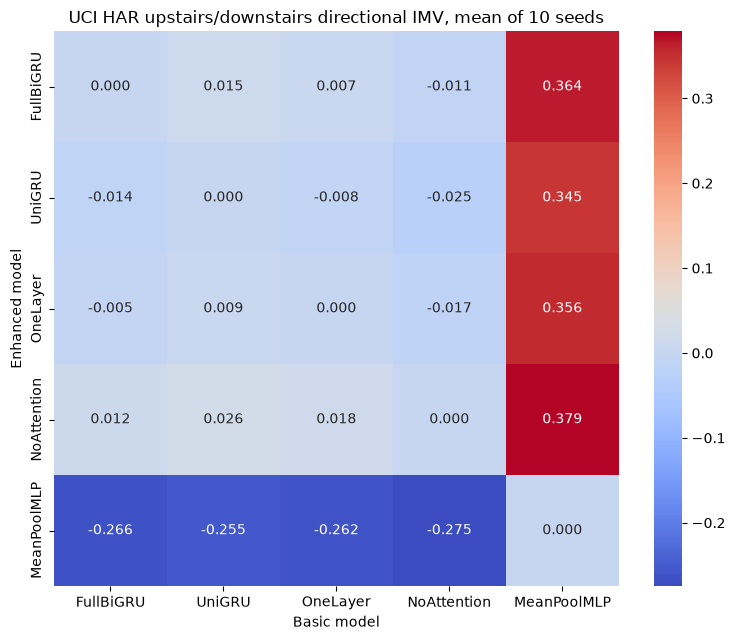

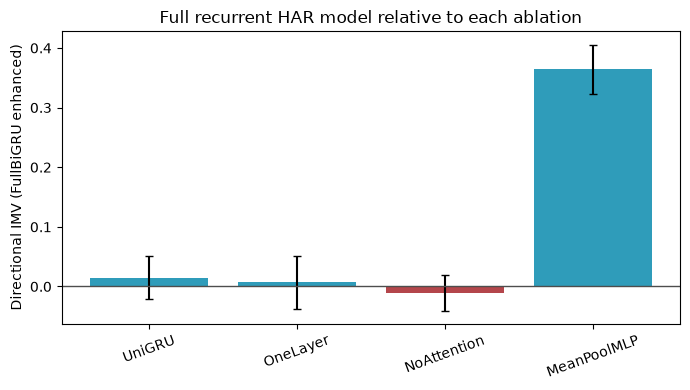

,mean,std
basic,,
UniGRU,0.014839,0.036055
OneLayer,0.006852,0.044893
NoAttention,-0.010723,0.029543
MeanPoolMLP,0.364011,0.041638


In [7]:
fig, ax = plot_ablation_matrix(
    mean_matrix,
    figsize=(7.8, 6.5),
    title=f"UCI HAR upstairs/downstairs directional IMV, mean of {len(SEEDS)} seeds",
)
ax.set_xlabel("Basic model")
ax.set_ylabel("Enhanced model")
fig.tight_layout()
matrix_paths = {file_format: relative_path(path, start=ARTIFACTS)
                for file_format, path in save_figure(
                    fig, FIGURES / "har_ablation_imv"
                ).items()}
plt.show()

full_vs_ablation = (
    by_seed[(by_seed["enhanced"] == "FullBiGRU") & (by_seed["basic"] != "FullBiGRU")]
    .groupby("basic", sort=False)["ablation_imv"]
    .agg(["mean", "std"])
    .reindex(VARIANTS[1:])
)
full_vs_ablation.to_csv(RESULTS / "har_full_vs_ablation.csv")

fig2, ax2 = plt.subplots(figsize=(7, 4))
colors = ["#2f9cba" if value >= 0 else "#b4464b" for value in full_vs_ablation["mean"]]
ax2.bar(
    full_vs_ablation.index,
    full_vs_ablation["mean"],
    yerr=full_vs_ablation["std"].fillna(0),
    capsize=3,
    color=colors,
)
ax2.axhline(0, color="0.3", linewidth=1)
ax2.set_ylabel("Directional IMV (FullBiGRU enhanced)")
ax2.set_title("Full recurrent HAR model relative to each ablation")
ax2.tick_params(axis="x", rotation=20)
fig2.tight_layout()
comparison_paths = {file_format: relative_path(path, start=ARTIFACTS)
                    for file_format, path in save_figure(
                        fig2, FIGURES / "har_full_vs_ablation"
                    ).items()}
plt.show()
full_vs_ablation